In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-price-prediction-dataset/House Price Prediction Dataset.csv


# Importing Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# I will import other libraires throught the way

# Importing dataset

In [3]:
df=pd.read_csv('/kaggle/input/house-price-prediction-dataset/House Price Prediction Dataset.csv')
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


# Basic EDA

In [4]:
df.shape # to know size of the dataset

(2000, 10)

In [5]:
# basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [6]:
# detailed statistical information about the dataset
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [7]:
# Check null values
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

which means there are no null values

In [8]:
# check duplicated values
df.duplicated().sum()

np.int64(0)

which means there are no duplicated values and our data is clean

# Visual EDA

In [9]:
df.nunique()

Id           2000
Area         1622
Bedrooms        5
Bathrooms       4
Floors          3
YearBuilt     124
Location        4
Condition       4
Garage          2
Price        1999
dtype: int64

In [10]:
# we can drop the Id feature cause its unique for each column and it'll not add any value in our model
df.drop(columns=['Id'],inplace=True)

In [11]:
num_cols=df.select_dtypes(include=['int64'])
num_cols

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
0,1360,5,4,3,1970,149919
1,4272,5,4,3,1958,424998
2,3592,2,2,3,1938,266746
3,966,4,2,2,1902,244020
4,4926,1,4,2,1975,636056
...,...,...,...,...,...,...
1995,4994,5,4,3,1923,295620
1996,3046,5,2,1,2019,580929
1997,1062,5,1,2,1903,476925
1998,4062,3,1,2,1936,161119


In [12]:
cat_cols=df.select_dtypes(include=['object'])
cat_cols

,Location,Condition,Garage
0,Downtown,Excellent,No
1,Downtown,Excellent,No
2,Downtown,Good,No
3,Suburban,Fair,Yes
4,Downtown,Fair,Yes
...,...,...,...
1995,Suburban,Poor,No
1996,Suburban,Poor,Yes
1997,Rural,Poor,No
1998,Urban,Excellent,Yes


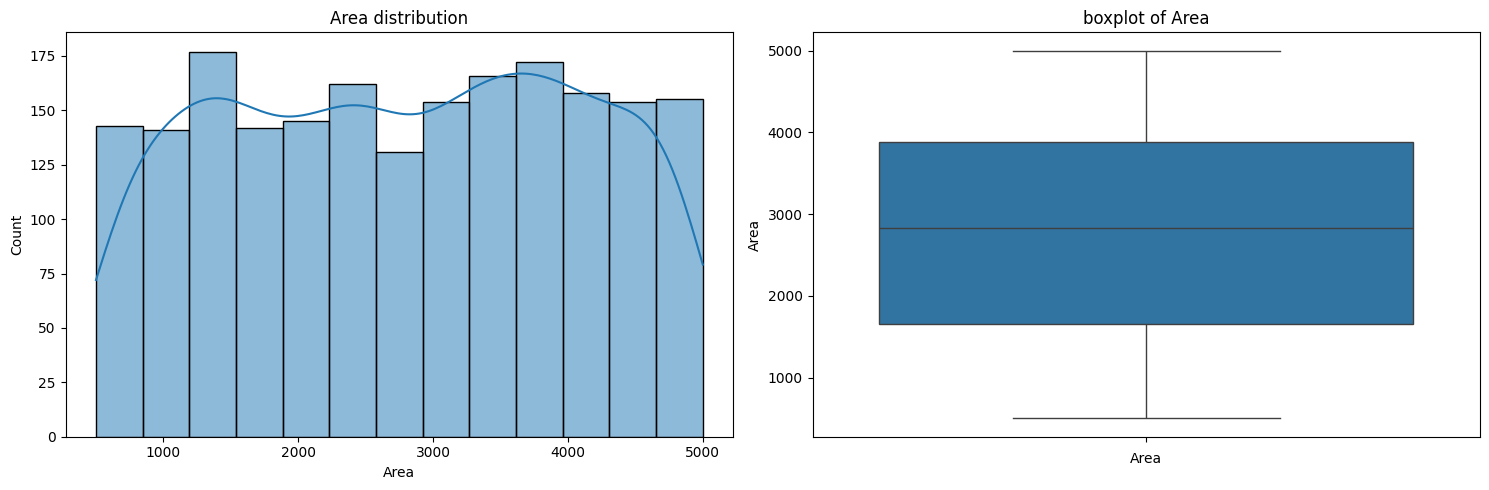

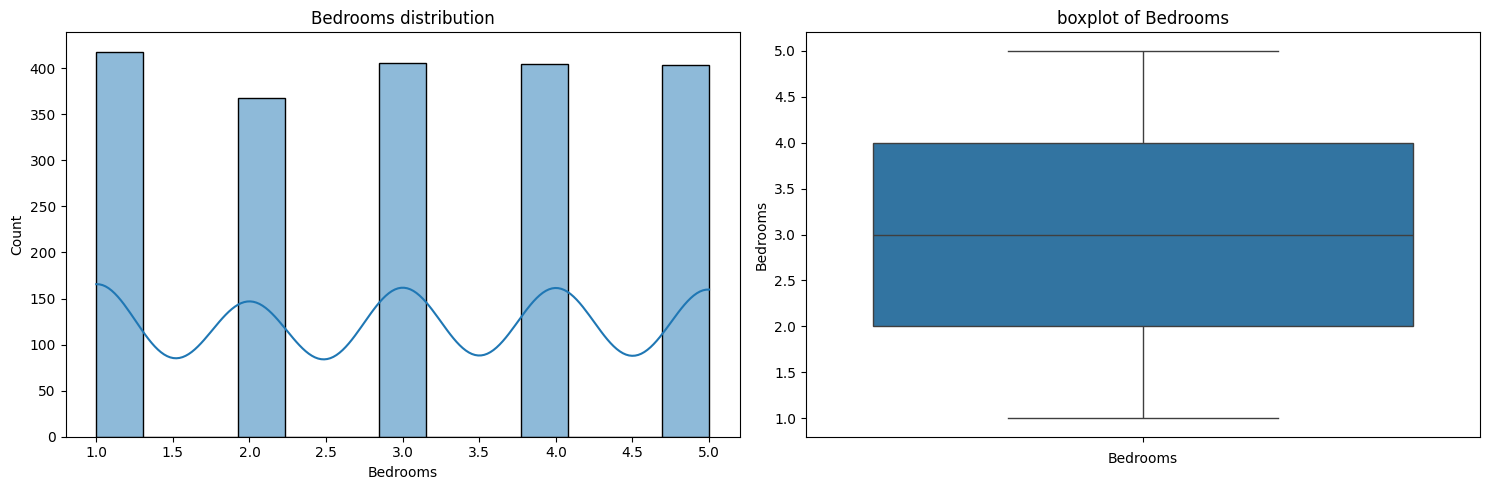

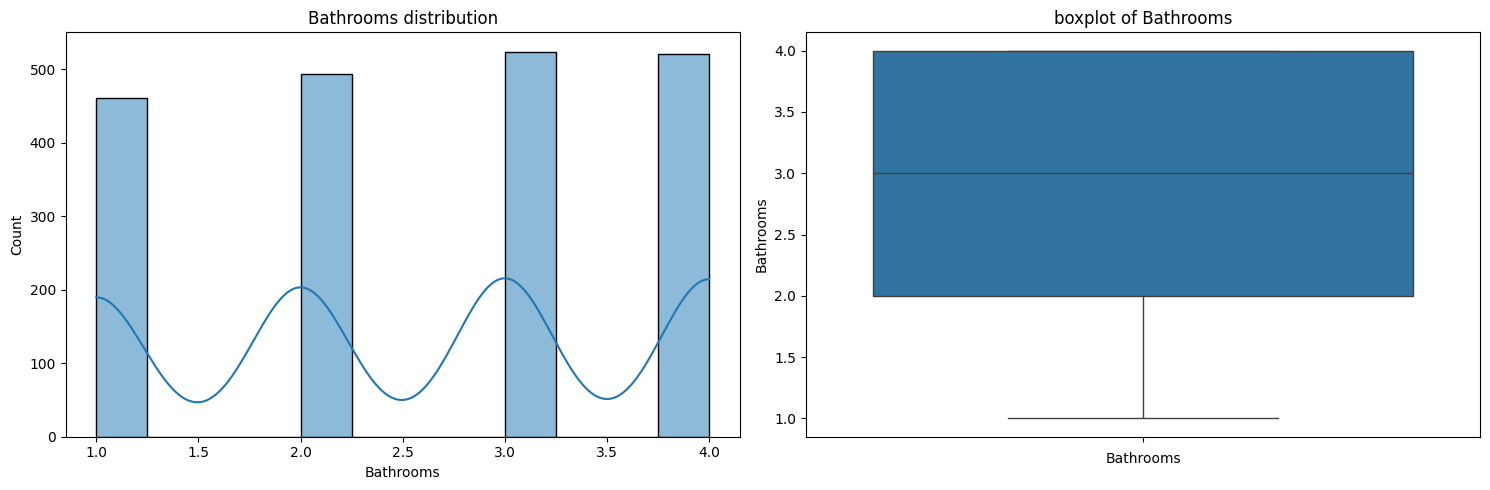

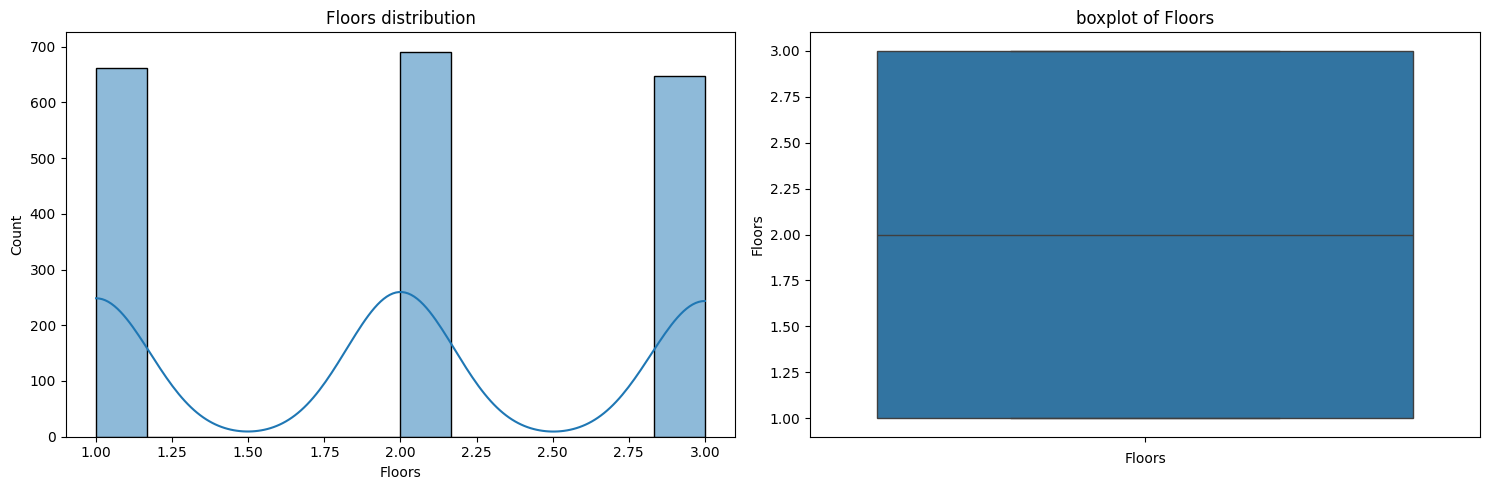

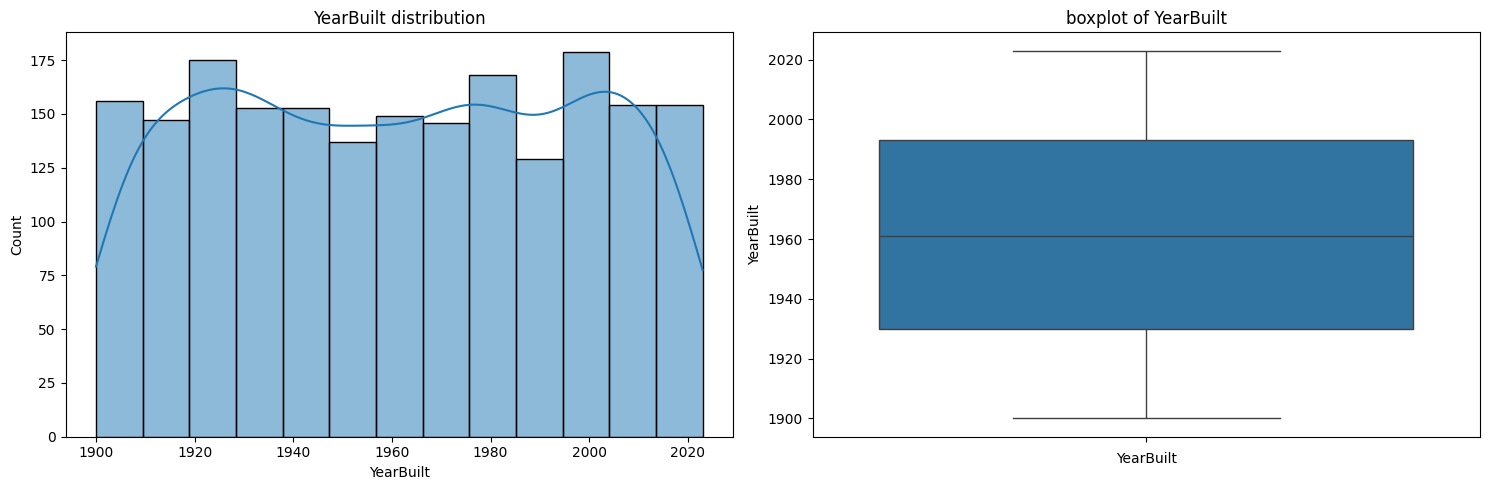

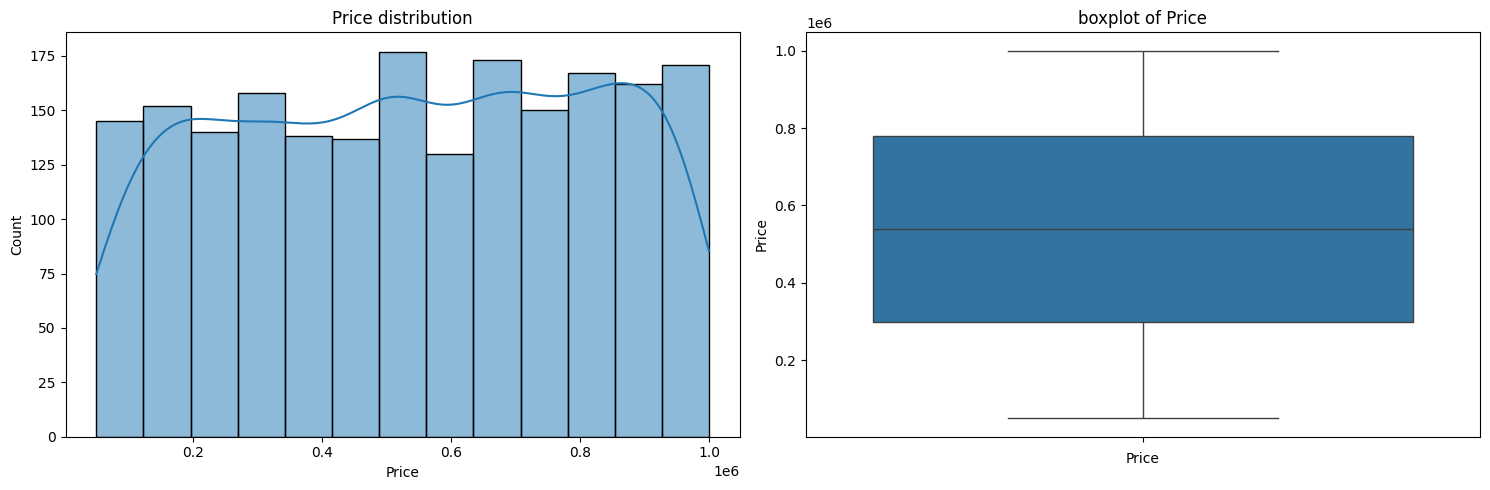

In [13]:
for i in num_cols:
    plt.figure(figsize = (15,5))
    plt.subplot(1,2,1)
    sns.histplot(df[i],edgecolor='black',kde=True)
    plt.title(f"{i} distribution")
    plt.xlabel(f"{i}")
    
    plt.subplot(1,2,2)
    sns.boxplot(df[i])
    plt.title(f"boxplot of {i}")
    plt.xlabel(f"{i}")
    plt.tight_layout()
    plt.show()

which shows the data is fairly distributed and there is no outliers

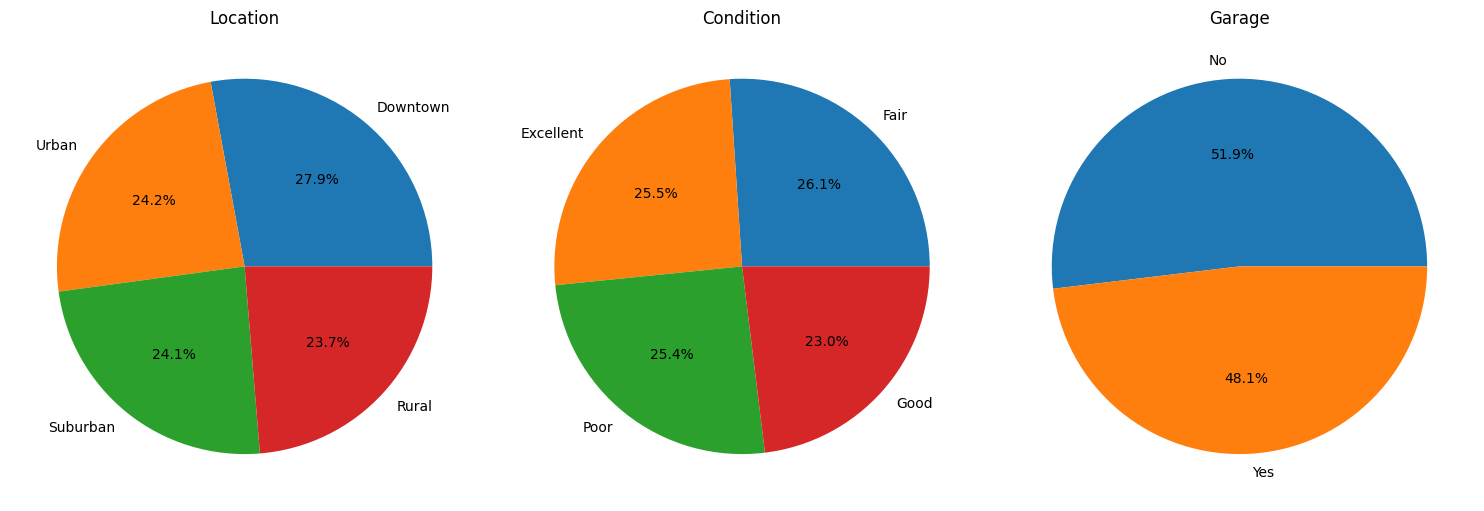

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

for i, col in enumerate(cat_cols.columns, 1):
    plt.subplot(1, len(cat_cols.columns), i)
    cat_cols[col].value_counts().plot.pie(autopct='%1.1f%%')
    plt.title(col)
    plt.ylabel("")

plt.tight_layout()
plt.show()

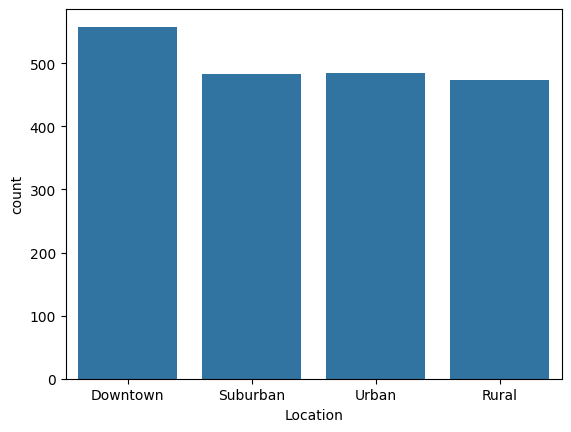

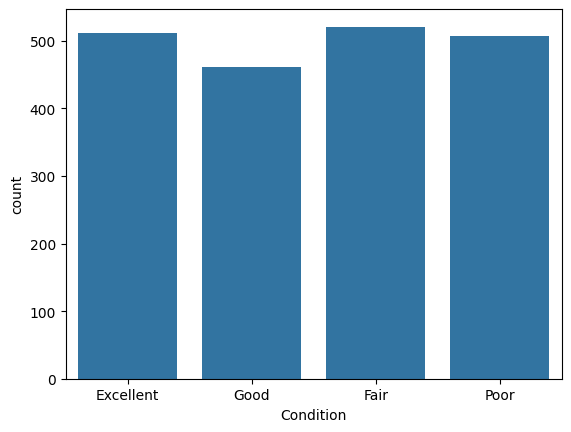

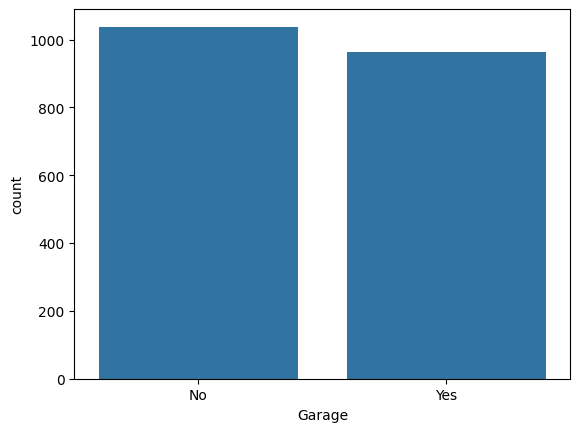

In [15]:
for i in cat_cols:
    sns.countplot(data=cat_cols,x=i)
    plt.show()

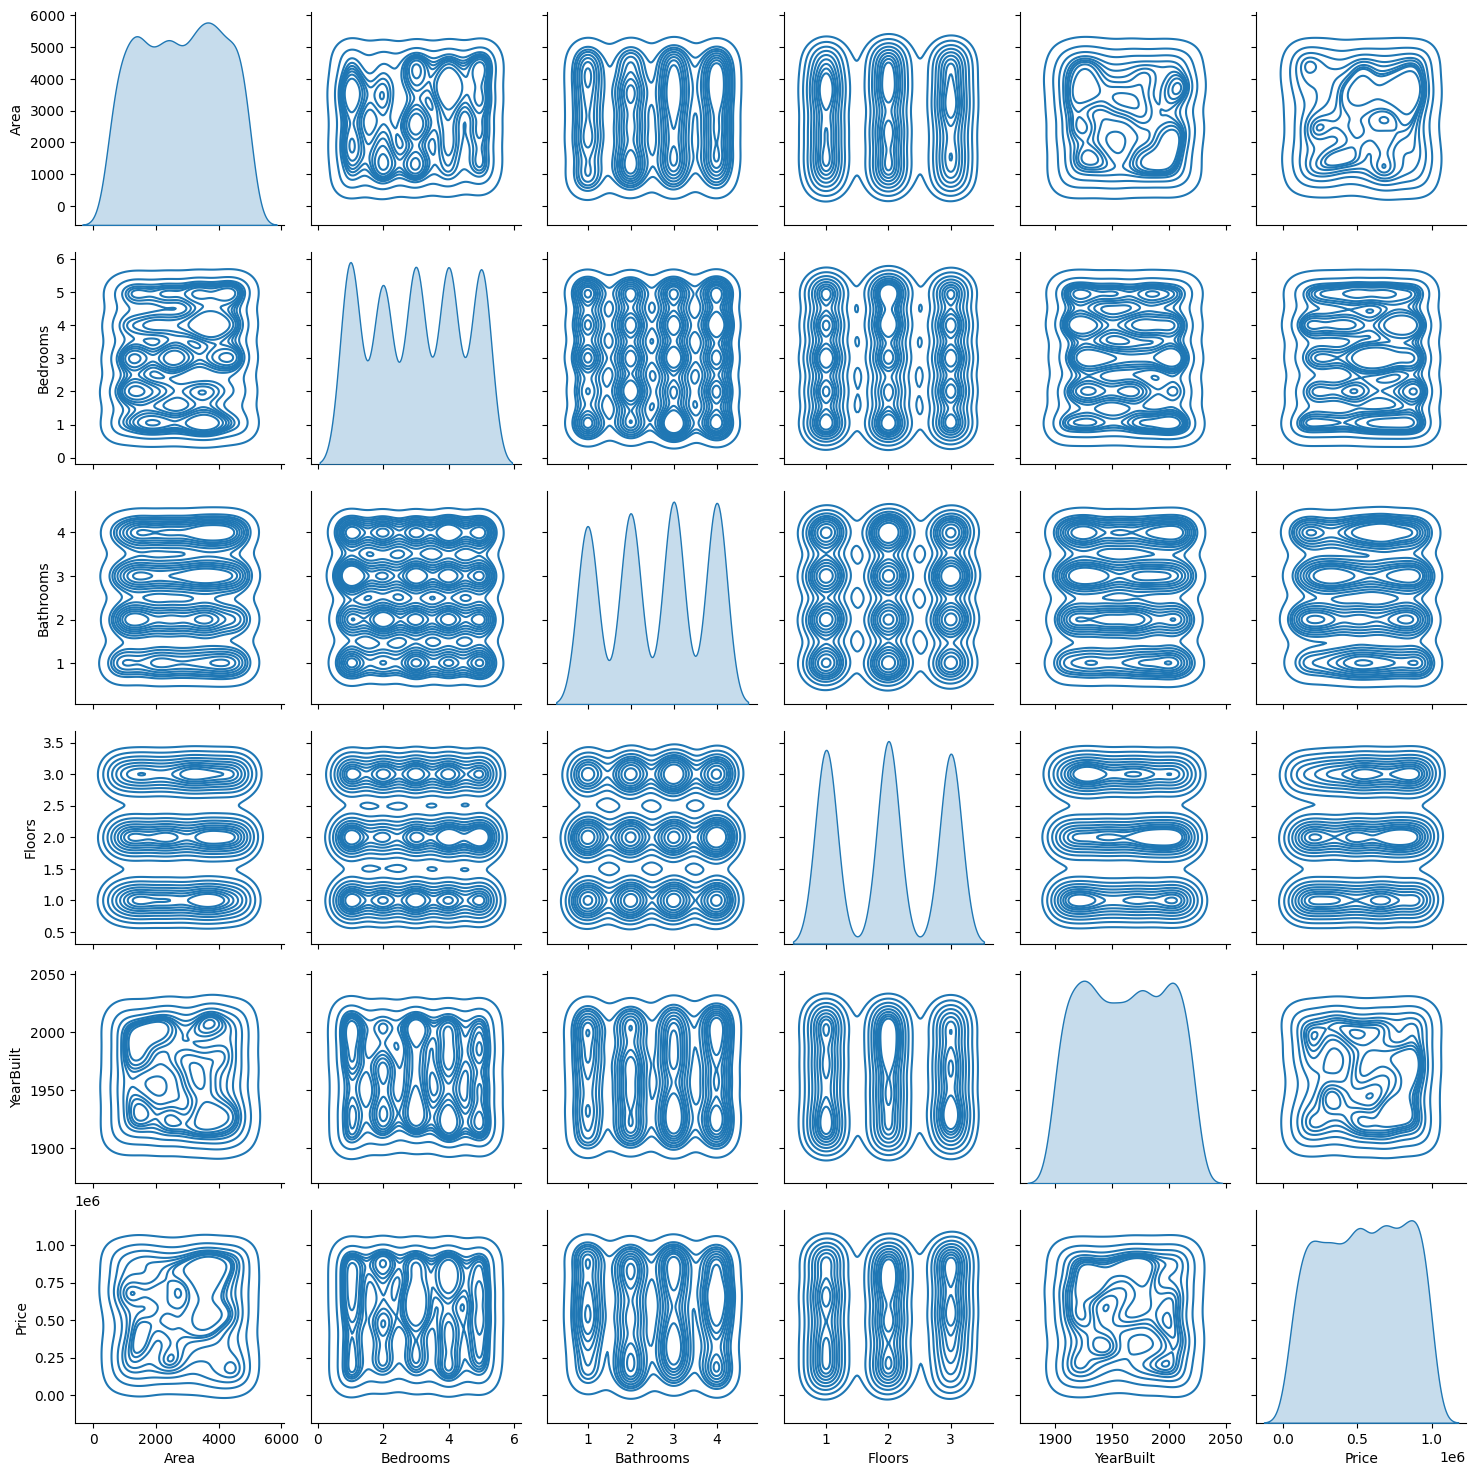

In [16]:
sns.pairplot(data=df, kind="kde")
plt.show()

# Data preprocessing

In [17]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [18]:
for i in cat_cols:
    df[i]=le.fit_transform(df[i])

In [19]:
df

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,0,0,0,149919
1,4272,5,4,3,1958,0,0,0,424998
2,3592,2,2,3,1938,0,2,0,266746
3,966,4,2,2,1902,2,1,1,244020
4,4926,1,4,2,1975,0,1,1,636056
...,...,...,...,...,...,...,...,...,...
1995,4994,5,4,3,1923,2,3,0,295620
1996,3046,5,2,1,2019,2,3,1,580929
1997,1062,5,1,2,1903,1,3,0,476925
1998,4062,3,1,2,1936,3,0,1,161119


## Heatmap

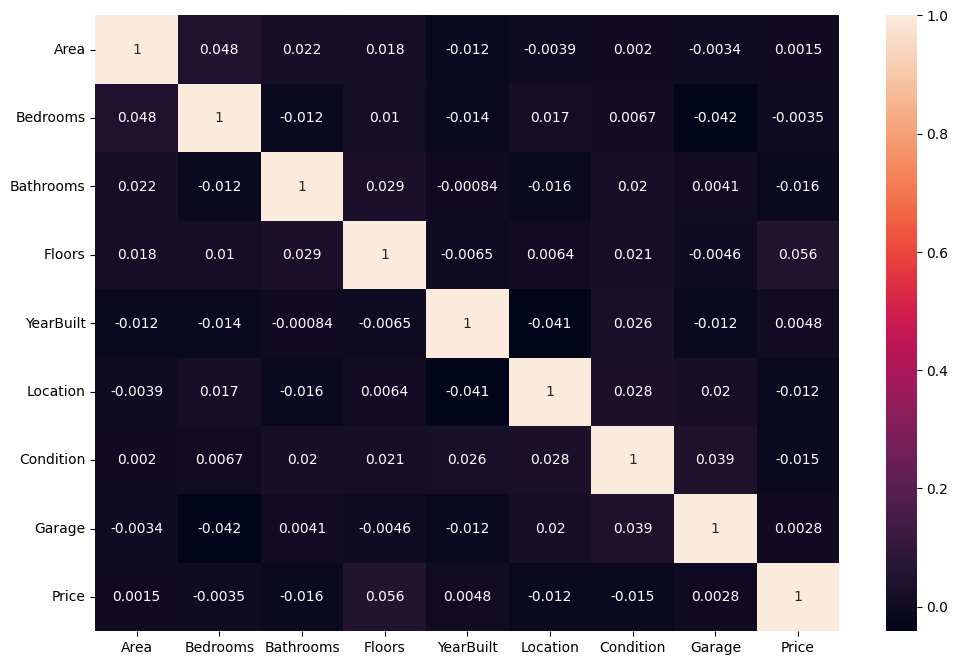

In [20]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [21]:
df_corr=abs(df.corr()['Price']).sort_values()
df_corr

Area         0.001542
Garage       0.002842
Bedrooms     0.003471
YearBuilt    0.004845
Location     0.012289
Condition    0.015036
Bathrooms    0.015737
Floors       0.055890
Price        1.000000
Name: Price, dtype: float64

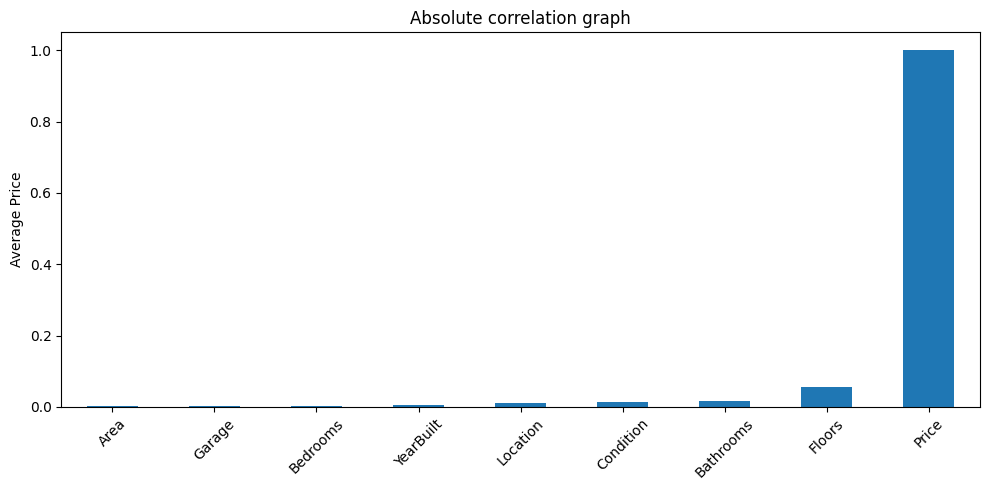

In [22]:
df_corr.plot(kind='bar',figsize=(10,5), title="Absolute correlation graph")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
selected_features=df_corr[df_corr>=0.01].index

In [24]:
selected_features

Index(['Location', 'Condition', 'Bathrooms', 'Floors', 'Price'], dtype='object')

In [25]:
final_df=df[selected_features]
final_df

,Location,Condition,Bathrooms,Floors,Price
0,0,0,4,3,149919
1,0,0,4,3,424998
2,0,2,2,3,266746
3,2,1,2,2,244020
4,0,1,4,2,636056
...,...,...,...,...,...
1995,2,3,4,3,295620
1996,2,3,2,1,580929
1997,1,3,1,2,476925
1998,3,0,1,2,161119


# Spliting our data

In [26]:
X=df.drop(columns=['Price'])
y=df['Price']

## Train-Test-Split

In [27]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42)

# Modeling

## Linear Regression

In [28]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'R² Score: {r2:.4f}')

Mean Squared Error (MSE): 78729422262.6482
Mean Absolute Error (MAE): 244419.9990
R² Score: -0.0120


## Random Forest

In [30]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor()

In [31]:
rf.fit(x_train,y_train)

RandomForestRegressor()

In [32]:
y_pred=rf.predict(x_test)

In [33]:
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.3f}")

MAE  : 251095.89
RMSE : 292199.99
R²   : -0.097


In [34]:
from sklearn.model_selection import cross_val_score
cvs=cross_val_score(rf,X,y,cv=10)
print(f"cross validation score is :- {cvs}")

cross validation score is :- [-0.09846599 -0.03713806 -0.05329406 -0.0854535  -0.05872275 -0.11009309
 -0.10185165 -0.10154674 -0.04747039 -0.05016034]


In [35]:
# mean of avg of cross validation scores
cvs.mean() 

np.float64(-0.07441965639125603)

In [36]:
import numpy as np
from sklearn.metrics import confusion_matrix
y_pred_labels = (y_pred >= 0.5).astype(int)
cf = confusion_matrix(y_test, y_pred_labels)
cf

array([[0, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0]])

**Couldn't make the model i wanted if you have any suggestion to improve let me know and if u like this notebook by any chance dont forget to upvote :)**